# 🌽 Maize Disease Recognition using Deep CNN

**Diseases Covered:**
- Bacterial Leaf Streak
- Common Rust
- Gray Leaf Spot
- Healthy
- Maize Chlorotic Mottle Virus
- Maize Streak Virus
- Northern Leaf Blight

**Pipeline:**
1. Mount Google Drive and extract maizedata.zip
2. Split data into train/validation/test (70/15/15)
3. Preprocess & Augment images
4. Build the 15-layer CNN
5. Train the model
6. Evaluate with confusion matrix, F1-score, MCC, etc.

## Step 1: Mount Google Drive and Extract Dataset

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

# Copy and extract the zip file from Google Drive
import zipfile
import shutil
import os

zip_path = '/content/gdrive/My Drive/maizedata.zip'  # Update path if needed
extract_dir = 'maize_dataset'

if os.path.exists(zip_path):
    # Copy to current directory (faster extraction)
    shutil.copy(zip_path, 'maizedata.zip')

    # Extract
    with zipfile.ZipFile('maizedata.zip', 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f'Extracted to {extract_dir}')

    # Clean up zip file to save space
    os.remove('maizedata.zip')
else:
    print(f'ERROR: {zip_path} not found! Make sure the file is in your Google Drive.')

Mounted at /content/gdrive
Extracted to maize_dataset


## Step 2: Split Dataset into Train/Validation/Test

In [2]:
import os
import shutil
import random
from pathlib import Path
from PIL import Image

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)

# Configuration
SOURCE_DIR = 'maize_dataset'  # Extracted folder
OUTPUT_DIR = 'dataset_split'
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Validate and filter image files
def is_valid_image(filepath):
    try:
        img = Image.open(filepath)
        img.verify()
        return True
    except:
        return False

# Find the actual data directory
def find_data_dir(base_dir):
    for root, dirs, files in os.walk(base_dir):
        if dirs:
            for d in dirs:
                check_path = os.path.join(root, d)
                if os.path.isdir(check_path):
                    contents = os.listdir(check_path)
                    if contents:
                        ext = contents[0].lower()
                        if ext.endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                            return root
    return base_dir

source_path = find_data_dir(SOURCE_DIR)
print(f'Using data from: {source_path}')

class_names = [d for d in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, d))]
print(f'Classes found: {class_names}')

for split in ['train', 'val', 'test']:
    for class_name in class_names:
        os.makedirs(os.path.join(OUTPUT_DIR, split, class_name), exist_ok=True)

VALID_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp')

for class_name in class_names:
    class_dir = os.path.join(source_path, class_name)
    all_files = os.listdir(class_dir)

    valid_images = []
    invalid_count = 0
    for f in all_files:
        if f.lower().endswith(VALID_EXTENSIONS):
            fpath = os.path.join(class_dir, f)
            if is_valid_image(fpath):
                valid_images.append(f)
            else:
                invalid_count += 1
                print(f'Invalid image removed: {class_name}/{f}')

    random.shuffle(valid_images)

    n_total = len(valid_images)
    n_train = int(n_total * TRAIN_RATIO)
    n_val = int(n_total * VAL_RATIO)

    train_images = valid_images[:n_train]
    val_images = valid_images[n_train:n_train + n_val]
    test_images = valid_images[n_train + n_val:]

    for img in train_images:
        shutil.copy2(os.path.join(class_dir, img), os.path.join(OUTPUT_DIR, 'train', class_name, img))
    for img in val_images:
        shutil.copy2(os.path.join(class_dir, img), os.path.join(OUTPUT_DIR, 'val', class_name, img))
    for img in test_images:
        shutil.copy2(os.path.join(class_dir, img), os.path.join(OUTPUT_DIR, 'test', class_name, img))

    print(f'{class_name}: {len(train_images)} train, {len(val_images)} val, {len(test_images)} test (removed {invalid_count} invalid)')


Using data from: maize_dataset/Corn_all_data
Classes found: ['Healthy', 'Maize_Streak_Virus', 'Gray_Leaf_Spot', 'Maize_Chlorotic_Mottle_Virus', 'Northern_Leaf_Blight', 'Bacterial_Leaf_Streak', 'Common_Rust']
Healthy: 3689 train, 790 val, 792 test (removed 0 invalid)
Maize_Streak_Virus: 2136 train, 457 val, 459 test (removed 0 invalid)
Gray_Leaf_Spot: 1026 train, 220 val, 221 test (removed 0 invalid)
Invalid image removed: Maize_Chlorotic_Mottle_Virus/MLN_1360.JPEG
Maize_Chlorotic_Mottle_Virus: 2323 train, 497 val, 499 test (removed 1 invalid)
Northern_Leaf_Blight: 802 train, 171 val, 173 test (removed 0 invalid)
Bacterial_Leaf_Streak: 133 train, 28 val, 29 test (removed 0 invalid)
Common_Rust: 1004 train, 215 val, 216 test (removed 0 invalid)


## Step 3: Import Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, matthews_corrcoef, accuracy_score
)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 4: Configuration & Hyperparameters

In [4]:
# ============================================================
#  CONFIGURATION
# ============================================================

BASE_DIR       = 'dataset_split'     # Split dataset folder
TRAIN_DIR      = os.path.join(BASE_DIR, 'train')
VAL_DIR        = os.path.join(BASE_DIR, 'val')
TEST_DIR       = os.path.join(BASE_DIR, 'test')

IMG_SIZE       = 227                  # Image size (227x227)
BATCH_SIZE     = 32
EPOCHS         = 70
LEARNING_RATE  = 0.001
NUM_CLASSES    = 7

CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])

print('Configuration set!')
print(f'Classes: {CLASS_NAMES}')
print(f'Number of classes: {NUM_CLASSES}')

Configuration set!
Classes: ['Bacterial_Leaf_Streak', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Maize_Chlorotic_Mottle_Virus', 'Maize_Streak_Virus', 'Northern_Leaf_Blight']
Number of classes: 7


## Step 5: Dataset Exploration


TRAIN SET:
----------------------------------------
  Bacterial_Leaf_Streak              : 133 images
  Common_Rust                        : 1004 images
  Gray_Leaf_Spot                     : 1026 images
  Healthy                            : 3689 images
  Maize_Chlorotic_Mottle_Virus       : 2323 images
  Maize_Streak_Virus                 : 2136 images
  Northern_Leaf_Blight               : 802 images
----------------------------------------
  Total: 11113 images

VALIDATION SET:
----------------------------------------
  Bacterial_Leaf_Streak              : 28 images
  Common_Rust                        : 215 images
  Gray_Leaf_Spot                     : 220 images
  Healthy                            : 790 images
  Maize_Chlorotic_Mottle_Virus       : 497 images
  Maize_Streak_Virus                 : 457 images
  Northern_Leaf_Blight               : 171 images
----------------------------------------
  Total: 2378 images

TEST SET:
----------------------------------------
  Bacter

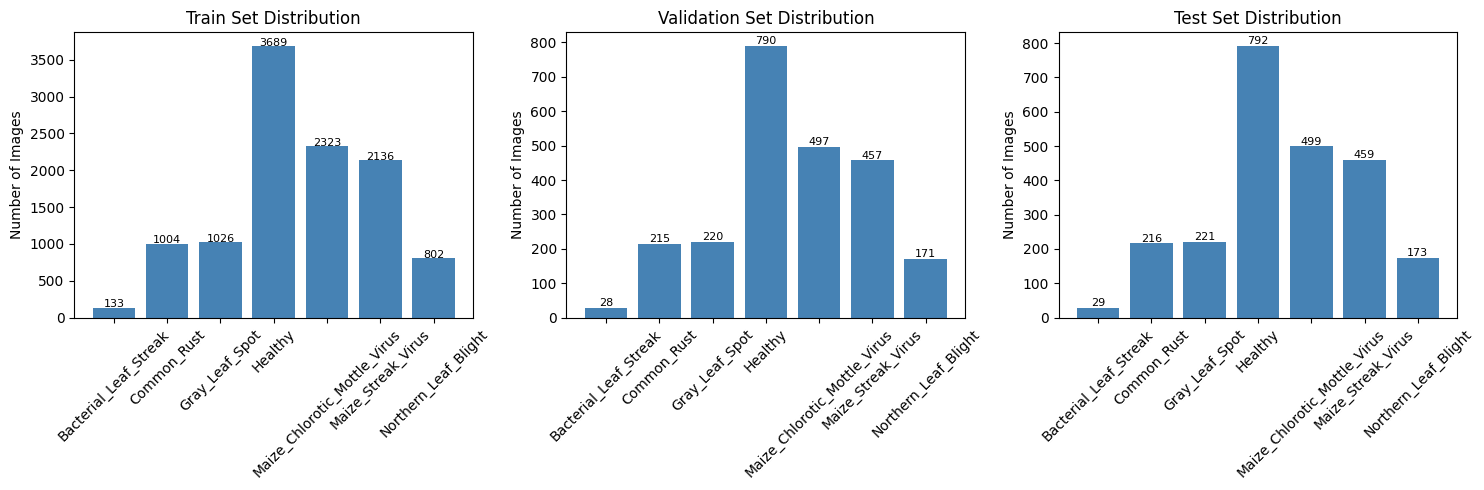

In [6]:
# Count images per class in each split
def count_images_in_split(split_dir, split_name):
    print(f'\n{split_name.upper()} SET:')
    print('-' * 40)
    total = 0
    class_counts = {}
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])
            class_counts[cls] = count
            total += count
            print(f'  {cls:<35}: {count} images')
    print('-' * 40)
    print(f'  Total: {total} images')
    return class_counts, total

train_counts, train_total = count_images_in_split(TRAIN_DIR, 'train')
val_counts, val_total = count_images_in_split(VAL_DIR, 'validation')
test_counts, test_total = count_images_in_split(TEST_DIR, 'test')

print(f'\nTOTAL: Train={train_total}, Val={val_total}, Test={test_total}')

# Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (data, title) in zip(axes, [(train_counts, 'Train'), (val_counts, 'Validation'), (test_counts, 'Test')]):
    bars = ax.bar(data.keys(), data.values(), color='steelblue')
    ax.set_title(f'{title} Set Distribution', fontsize=12)
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, data.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## Step 6: Data Preprocessing & Augmentation

In [7]:
# Training augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,                  # normalize to [0,1]
    rotation_range=20,                  # rotation
    shear_range=0.2,                    # shear
    zoom_range=0.2,                     # zoom
    horizontal_flip=True,              # flip horizontal
    vertical_flip=True,                 # flip vertical
    brightness_range=[0.8, 1.2],        # brightness
    fill_mode='nearest'
)

# Validation and Test - only rescaling
val_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

# Create generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

print(f'\nTraining samples   : {train_generator.samples}')
print(f'Validation samples : {val_generator.samples}')
print(f'Testing samples    : {test_generator.samples}')
print(f'Class indices      : {train_generator.class_indices}')

Found 11113 images belonging to 7 classes.
Found 2378 images belonging to 7 classes.
Found 2389 images belonging to 7 classes.

Training samples   : 11113
Validation samples : 2378
Testing samples    : 2389
Class indices      : {'Bacterial_Leaf_Streak': 0, 'Common_Rust': 1, 'Gray_Leaf_Spot': 2, 'Healthy': 3, 'Maize_Chlorotic_Mottle_Virus': 4, 'Maize_Streak_Virus': 5, 'Northern_Leaf_Blight': 6}


## Step 7: Visualize Sample Images

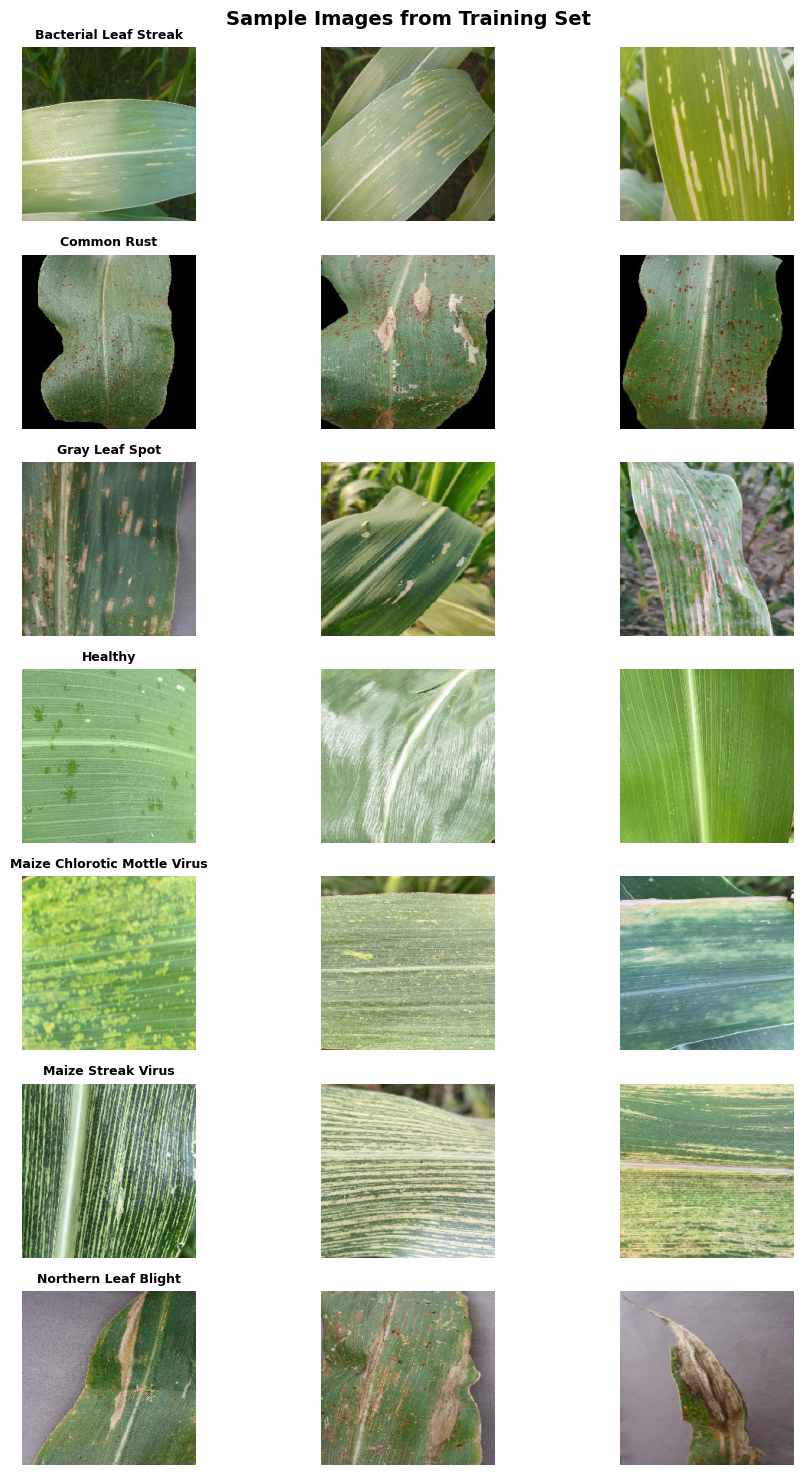

In [8]:
# Show sample images from each class
from tensorflow.keras.preprocessing.image import load_img

class_dirs = sorted(os.listdir(TRAIN_DIR))
num_classes = len(class_dirs)
num_samples = 3

fig, axes = plt.subplots(num_classes, num_samples, figsize=(10, 15))
if num_classes == 1:
    axes = axes.reshape(1, -1)

for row, cls in enumerate(class_dirs):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    imgs = random.sample(os.listdir(cls_path), min(num_samples, len(os.listdir(cls_path))))
    for col, fname in enumerate(imgs):
        img = load_img(os.path.join(cls_path, fname), target_size=(IMG_SIZE, IMG_SIZE))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls.replace('_', ' '), fontsize=9, fontweight='bold')

plt.suptitle('Sample Images from Training Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Build the 15-Layer CNN

In [9]:
def build_15layer_cnn(input_shape=(227, 227, 3), num_classes=7):
    """Build the 15-layer CNN model"""
    model = models.Sequential(name='Maize_Disease_CNN')

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(96, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 4
    model.add(layers.Conv2D(256, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Conv2D(384, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 5
    model.add(layers.Conv2D(384, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.GlobalAveragePooling2D())

    # Fully Connected Layers
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Build the model
model = build_15layer_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)

# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()

Model: "Maize_Disease_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 227, 227, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 227, 227, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 227, 227, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 227, 227, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 227, 227, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 227, 227, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 113, 113, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 113, 113, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 113, 113, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 113, 113, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 113, 113, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 113, 113, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 56, 56, 128)    │             

 Total params: 2,846,599 (10.86 MB)

 Trainable params: 2,843,207 (10.85 MB)

 Non-trainable params: 3,392 (13.25 KB)

## Step 9: Train the Model

In [10]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Custom callback to save every 5 epochs
class SaveEveryNEpochs(keras.callbacks.Callback):
    def __init__(self, save_dir, n=5):
        super().__init__()
        self.save_dir = save_dir
        self.n = n
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.n == 0:
            filepath = f'{self.save_dir}/model_epoch_{epoch+1:02d}.keras'
            self.model.save(filepath)
            print(f'\nSaved checkpoint: {filepath}')

import os
os.makedirs('/content/gdrive/My Drive/checkpoints', exist_ok=True)
callbacks.append(SaveEveryNEpochs('/content/gdrive/My Drive/checkpoints', n=5))

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

KeyboardInterrupt: 

## ⏸️ Resume Training (Run this after Colab resets)

In [11]:
# Find latest checkpoint and resume training
import os
import glob

checkpoint_dir = '/content/gdrive/My Drive/checkpoints'

if os.path.exists(checkpoint_dir):
    checkpoints = sorted(glob.glob(os.path.join(checkpoint_dir, 'model_epoch_*.keras')))

    if checkpoints:
        latest_checkpoint = checkpoints[-1]
        print(f'Found checkpoint: {latest_checkpoint}')

        # Extract epoch number from filename
        epoch_num = int(os.path.basename(latest_checkpoint).split('_')[-1].split('.')[0])
        print(f'Resuming from epoch {epoch_num}')

        # Load the model
        model = keras.models.load_model(latest_checkpoint)

        # Continue training
        additional_epochs = 20  # Set how many more epochs to train
        history = model.fit(
            train_generator,
            epochs=epoch_num + additional_epochs,
            initial_epoch=epoch_num,
            validation_data=val_generator,
            callbacks=callbacks,
            verbose=1
        )
    else:
        print('No checkpoints found. Starting fresh training.')
else:
    print('No checkpoint directory found. Starting fresh training.')


Found checkpoint: /content/gdrive/My Drive/checkpoints/model_epoch_45.keras
Resuming from epoch 45
Epoch 46/65
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9615 - loss: 0.1068
Epoch 46: val_accuracy improved from None to 0.94323, saving model to best_model.keras

Epoch 46: finished saving model to best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 528s 1s/step - accuracy: 0.9616 - loss: 0.1107 - val_accuracy: 0.9432 - val_loss: 0.1788 - learning_rate: 3.1250e-05
Epoch 47/65
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9674 - loss: 0.1000
Epoch 47: val_accuracy improved from 0.94323 to 0.94659, saving model to best_model.keras

Epoch 47: finished saving model to best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 462s 1s/step - accuracy: 0.9634 - loss: 0.1079 - val_accuracy: 0.9466 - val_loss: 0.1622 - learning_rate: 3.1250e-05
Epoch 48/65
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9621 - loss: 0.1070
Epoch 48: val_accuracy improved from 0.94659 to 0.94870, saving mode

## Step 10: Plot Training History

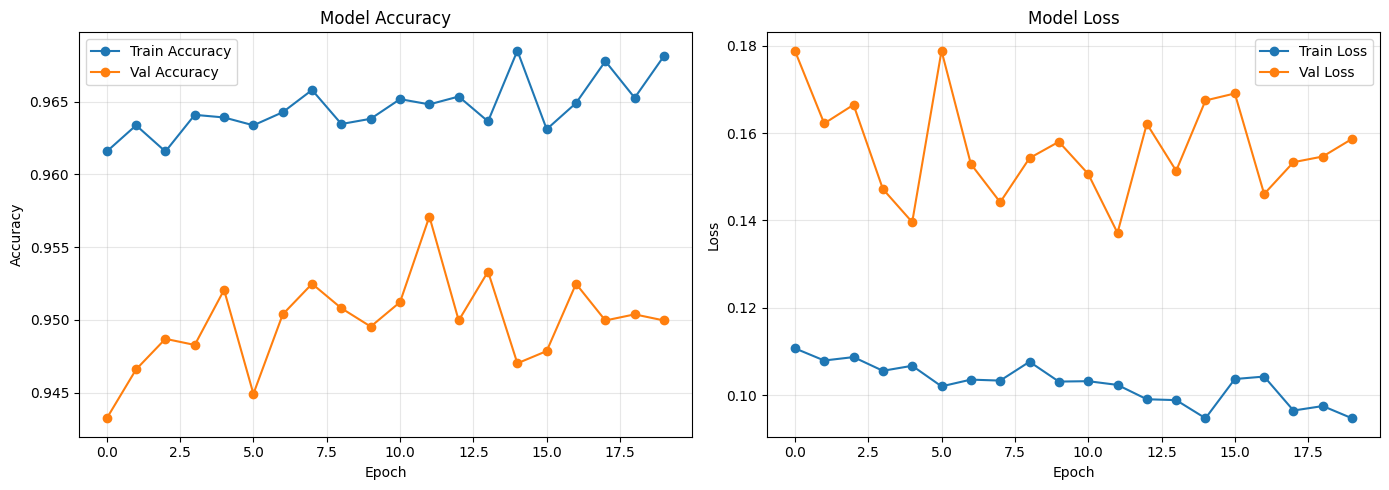

In [12]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
axes[0].set_title('Model Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Val Loss', marker='o')
axes[1].set_title('Model Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 11: Evaluate Model on Test Set

In [13]:
# Load best model
model.load_weights('best_model.keras')

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

75/75 ━━━━━━━━━━━━━━━━━━━━ 64s 826ms/step - accuracy: 0.9590 - loss: 0.1393

Test Loss: 0.1393
Test Accuracy: 0.9590


## Step 12: Confusion Matrix & Classification Report

75/75 ━━━━━━━━━━━━━━━━━━━━ 53s 671ms/step


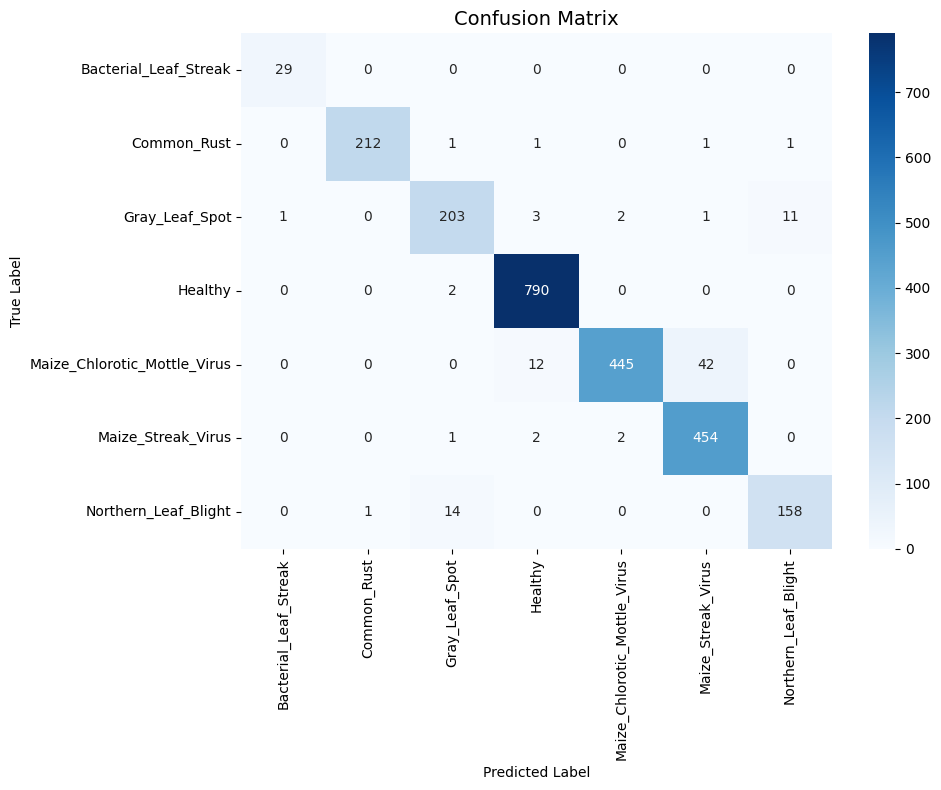


Classification Report:
------------------------------------------------------------
                              precision    recall  f1-score   support

       Bacterial_Leaf_Streak       0.97      1.00      0.98        29
                 Common_Rust       1.00      0.98      0.99       216
              Gray_Leaf_Spot       0.92      0.92      0.92       221
                     Healthy       0.98      1.00      0.99       792
Maize_Chlorotic_Mottle_Virus       0.99      0.89      0.94       499
          Maize_Streak_Virus       0.91      0.99      0.95       459
        Northern_Leaf_Blight       0.93      0.91      0.92       173

                    accuracy                           0.96      2389
                   macro avg       0.96      0.96      0.96      2389
                weighted avg       0.96      0.96      0.96      2389


Additional Metrics:
  Weighted F1 Score: 0.9587
  Matthews Corr Coef: 0.9483
  Accuracy: 0.9590


In [14]:
# Get predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

# Get class names
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Classification Report
print('\nClassification Report:')
print('-' * 60)
print(classification_report(y_true, y_pred, target_names=class_labels))

# Calculate additional metrics
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

print('\nAdditional Metrics:')
print(f'  Weighted F1 Score: {f1:.4f}')
print(f'  Matthews Corr Coef: {mcc:.4f}')
print(f'  Accuracy: {acc:.4f}')

## Step 13: Per-Class Performance

Per-Class Performance:
----------------------------------------------------------------------
Class                                Precision     Recall   F1-Score
----------------------------------------------------------------------
Bacterial_Leaf_Streak                   0.9667     1.0000     0.9831
Common_Rust                             0.9953     0.9815     0.9883
Gray_Leaf_Spot                          0.9186     0.9186     0.9186
Healthy                                 0.9777     0.9975     0.9875
Maize_Chlorotic_Mottle_Virus            0.9911     0.8918     0.9388
Maize_Streak_Virus                      0.9116     0.9891     0.9488
Northern_Leaf_Blight                    0.9294     0.9133     0.9213
----------------------------------------------------------------------


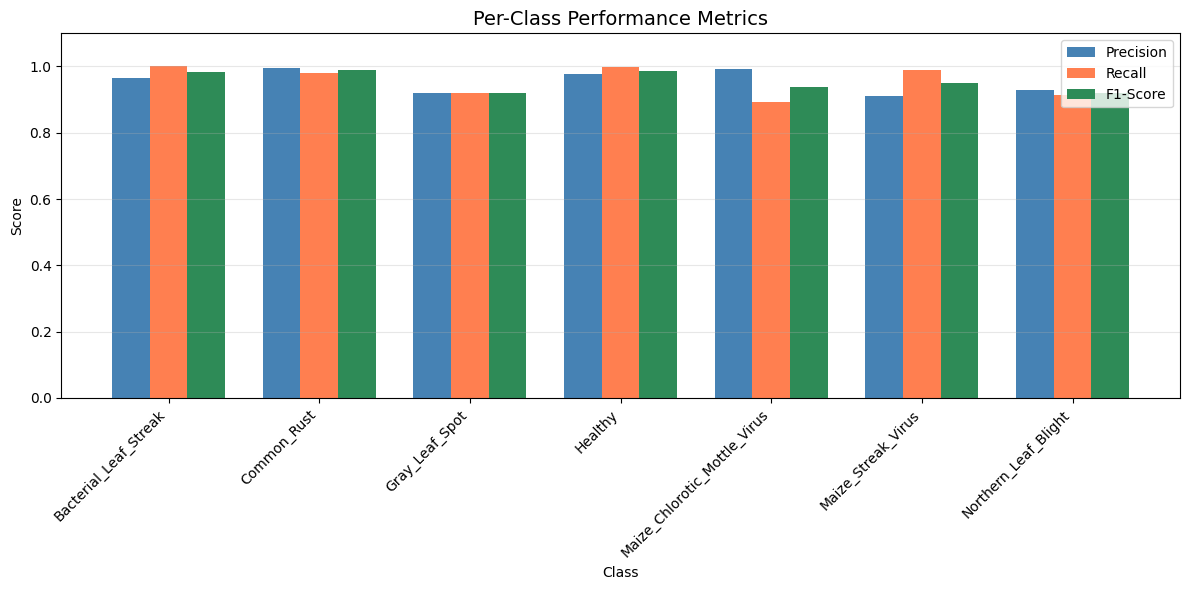

In [15]:
# Per-class metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)

print('Per-Class Performance:')
print('-' * 70)
print(f'{"Class":<35} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}')
print('-' * 70)
for i, cls in enumerate(class_labels):
    print(f'{cls:<35} {precision[i]:>10.4f} {recall[i]:>10.4f} {f1[i]:>10.4f}')
print('-' * 70)

# Plot per-class metrics
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_labels))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision', color='steelblue')
bars2 = ax.bar(x, recall, width, label='Recall', color='coral')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='seagreen')

ax.set_xlabel('Class')
ax.set_ylabel('Score')
ax.set_title('Per-Class Performance Metrics', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Step 14: Save Model

In [16]:
# Save the trained model
model.save('maize_disease_cnn_model.keras')
print('Model saved as: maize_disease_cnn_model.keras')

# Also save class labels for inference
import json

class_info = {'classes': CLASS_NAMES, 'class_indices': train_generator.class_indices}
with open('class_labels.json', 'w') as f:
    json.dump(class_info, f, indent=2)
print('Class labels saved as: class_labels.json')

Model saved as: maize_disease_cnn_model.keras
Class labels saved as: class_labels.json
